# Accuracy vs precision of data

Bananas are sold by weight. The checkout scales record the sales, and the forecasting model
learns from these records. What if the scales are **imprecise** (random noise) or
**inaccurate** (miscalibrated: they read too low)? We train on the *recorded* sales of 2024
and score the model against the *true* expected demand of 2025 (the pattern the model should
learn, without the day-to-day randomness of customers).

In [1]:
import altair as alt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge

import inventory_data as d
from inventory_data import viz

alt.renderers.enable("png", scale_factor=2)  # static images: GitHub shows them
viz.enable()

In [2]:
truth = d.truth().query("product_id == 101")
sales = d.sales().query("product_id == 101")[["date", "store_id", "promo"]]
weather = d.weather().merge(
    d.stores()[["id", "station"]].rename(columns={"id": "store_id"}), on="station"
)
bananas = truth.merge(sales, on=["date", "store_id"]).merge(
    weather[["date", "store_id", "temp_c"]], on=["date", "store_id"]
)
doy = bananas.date.dt.dayofyear
bananas = bananas.assign(
    dow=bananas.date.dt.dayofweek,
    season_sin=np.sin(2 * np.pi * doy / 365),
    season_cos=np.cos(2 * np.pi * doy / 365),
    promo=bananas.promo.astype(int),
)
FEATURES = ["store_id", "dow", "season_sin", "season_cos", "promo", "temp_c"]
train = bananas[bananas.date < "2025-01-01"].sort_values("date").reset_index(drop=True)
test = bananas[bananas.date >= "2025-01-01"].reset_index(drop=True)
pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "mean kg per store and day": [train.sales.mean().round(1), test.sales.mean().round(1)],
    },
    index=["train (2024)", "test (2025)"],
)

,rows,mean kg per store and day
train (2024),2928,27.5
test (2025),2920,28.3


Change the parameters and run the notebook again:

In [3]:
NOISE = 30  # noise of each reading (%, imprecise)
BIAS = 10  # the scales read too low by (%, inaccurate)

In [4]:
rng = np.random.default_rng(0)
eps = rng.normal(0, 1, len(train))
s, b = NOISE / 100, BIAS / 100
recorded = {
    "clean": train.sales.to_numpy(),
    "imprecise": np.maximum(train.sales * (1 + s * eps), 0).to_numpy(),
    "inaccurate": (train.sales * (1 - b)).to_numpy(),
    "both": np.maximum(train.sales * (1 - b) * (1 + s * eps), 0).to_numpy(),
}
CONDITIONS = list(recorded)

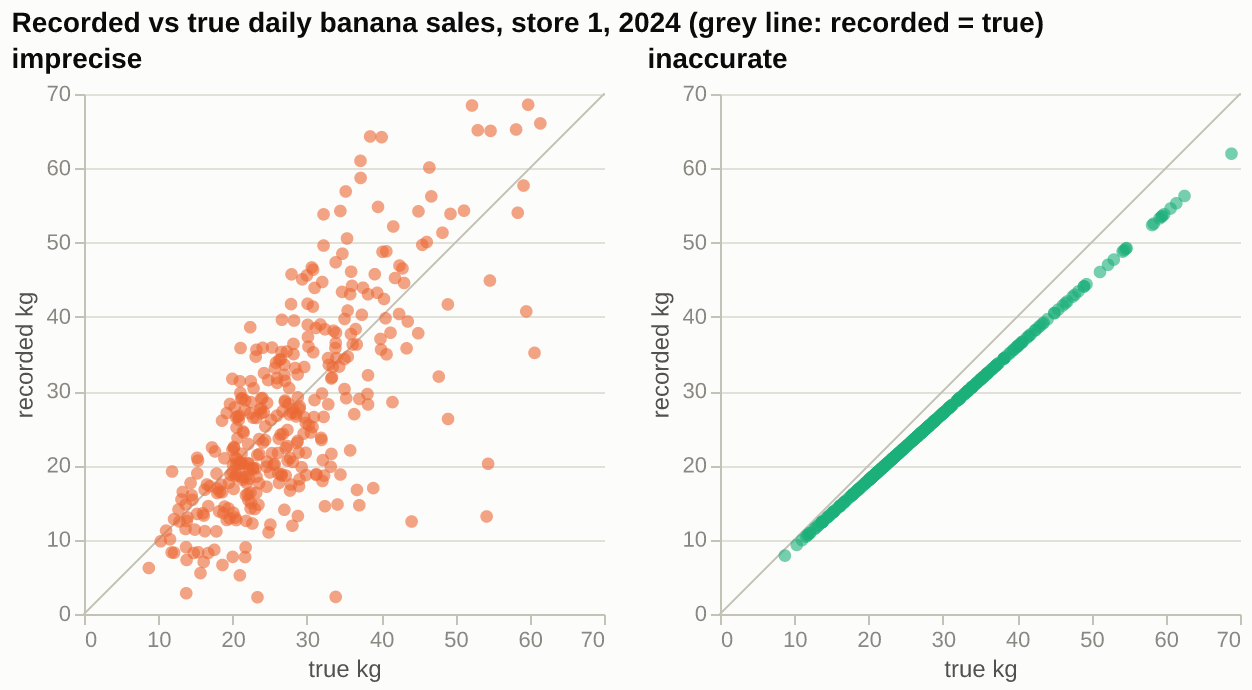

In [5]:
one = train.store_id == 1
points = pd.concat(
    [
        pd.DataFrame({"true kg": train.sales[one], "recorded kg": recorded[c][one], "data": c})
        for c in CONDITIONS[1:3]
    ]
)
diagonal = (
    alt.Chart(pd.DataFrame({"x": [0, 70], "y": [0, 70]}))
    .mark_line(color="#c3c2b7", strokeWidth=1)
    .encode(x=alt.X("x", title="true kg"), y=alt.Y("y", title="recorded kg"))
)


def scatter(kind):
    dots = (
        alt.Chart(points[points.data == kind])
        .mark_circle(size=40, opacity=0.6, clip=True)
        .encode(
            x=alt.X("true kg:Q", title="true kg", scale=alt.Scale(domain=[0, 70])),
            y=alt.Y("recorded kg:Q", title="recorded kg", scale=alt.Scale(domain=[0, 70])),
            color=alt.Color(
                "data:N",
                scale=alt.Scale(
                    domain=CONDITIONS, range=["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
                ),
                legend=None,
            ),
            tooltip=[
                "data",
                alt.Tooltip("true kg:Q", format=".1f"),
                alt.Tooltip("recorded kg:Q", format=".1f"),
            ],
        )
    )
    return (diagonal + dots).properties(width=260, height=260, title=kind)


alt.hconcat(scatter("imprecise"), scatter("inaccurate")).properties(
    title="Recorded vs true daily banana sales, store 1, 2024 (grey line: recorded = true)"
)

In [6]:
SIZES = [14, 28, 56, 112, 224, 366]


def fit_score(X, y, model):
    if model == "linear":

        def enc(f):
            return pd.get_dummies(f.astype({"store_id": str, "dow": str}), dtype=float)

        cols = enc(X).columns
        m = Ridge(alpha=1.0).fit(enc(X), y)
        pred = m.predict(enc(test[FEATURES]).reindex(columns=cols, fill_value=0))
    else:
        m = HistGradientBoostingRegressor(
            max_iter=60, categorical_features=[0, 1], random_state=0
        ).fit(X, y)
        pred = m.predict(test[FEATURES])
    err = pred - test.expected_demand
    return float(np.mean(np.abs(err))), float(np.mean(err))

In [7]:
all_days = np.sort(train.date.unique())
samples = [np.random.default_rng(k).permutation(all_days) for k in range(3)]


def subset(n, k):
    return train.date.isin(samples[k][:n]).to_numpy()

In [8]:
rows = []
for c in CONDITIONS:
    for n in SIZES:
        scores = [
            fit_score(train[FEATURES][subset(n, k)], recorded[c][subset(n, k)], "boosting")
            for k in range(3)
        ]
        rows.append(
            {
                "days of training data": n,
                "data": c,
                "MAE (kg)": np.mean([sc[0] for sc in scores]),
                "mean error (kg)": np.mean([sc[1] for sc in scores]),
            }
        )
curves = pd.DataFrame(rows)

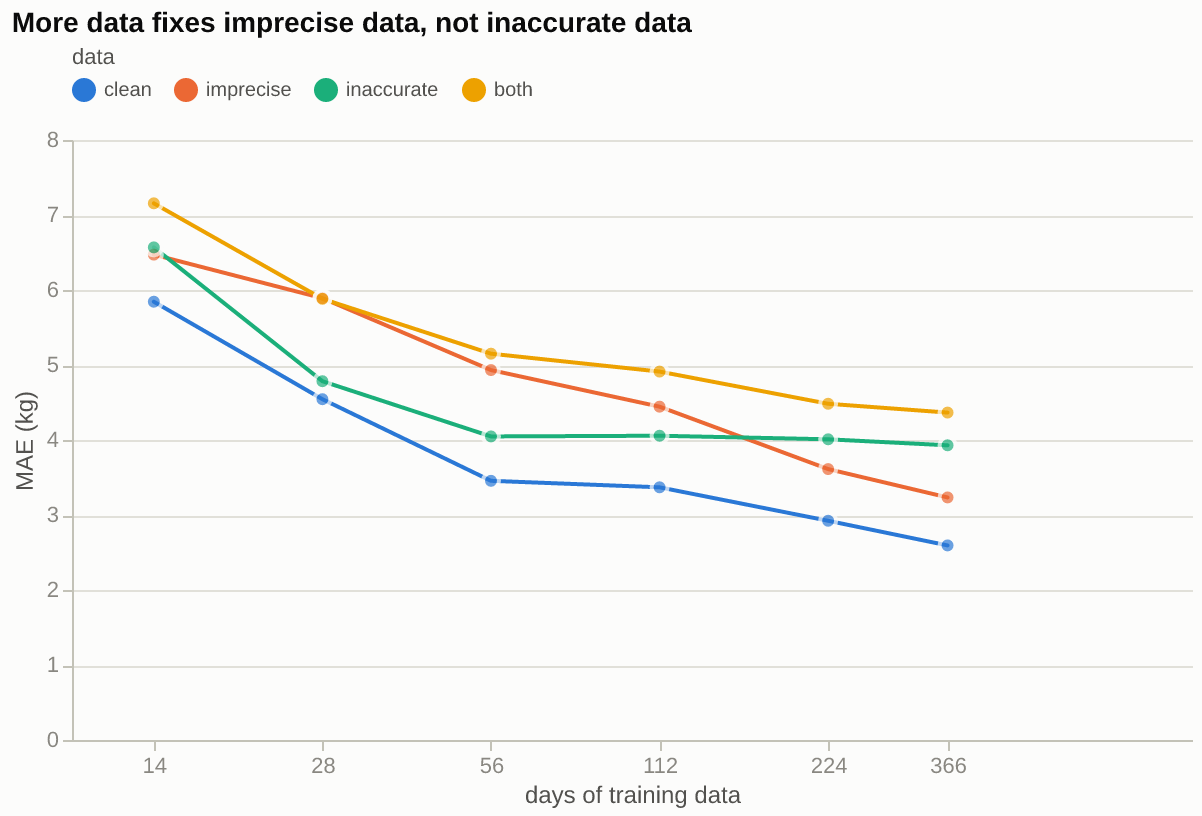

Mean absolute error against the true expected demand of 2025 (kg per store and day):

data,clean,imprecise,inaccurate,both
days of training data,,,,
14,5.84,6.47,6.57,7.16
28,4.54,5.89,4.78,5.88
56,3.46,4.93,4.05,5.15
112,3.37,4.44,4.06,4.91
224,2.92,3.61,4.01,4.48
366,2.59,3.23,3.93,4.37


Mean error with all 366 days (negative = the model predicts too little): clean -0.88 kg, imprecise -1.13 kg, inaccurate -3.61 kg, both -3.84 kg

In [9]:
base = alt.Chart(curves).encode(
    x=alt.X(
        "days of training data:Q",
        scale=alt.Scale(type="log"),
        axis=alt.Axis(values=[14, 28, 56, 112, 224, 366]),
    ),
    y=alt.Y("MAE (kg):Q", scale=alt.Scale(zero=True)),
    color=alt.Color("data:N", sort=CONDITIONS),
    tooltip=["data", "days of training data", alt.Tooltip("MAE (kg):Q", format=".2f")],
)
chart = (base.mark_line() + base.mark_point()).properties(
    width=560, height=300, title="More data fixes imprecise data, not inaccurate data"
)
table = curves.pivot(index="days of training data", columns="data", values="MAE (kg)")[
    CONDITIONS
].round(2)
bias_row = curves[curves["days of training data"] == 366].set_index("data")["mean error (kg)"]
display(chart)
display(
    Markdown("Mean absolute error against the true expected demand of 2025 (kg per store and day):")
)
display(table)
display(
    Markdown(
        "Mean error with all 366 days (negative = the model predicts too little): "
        + ", ".join(f"{k} {v:+.2f} kg" for k, v in bias_row[CONDITIONS].items())
    )
)

### Better model or more data? (imprecise data)

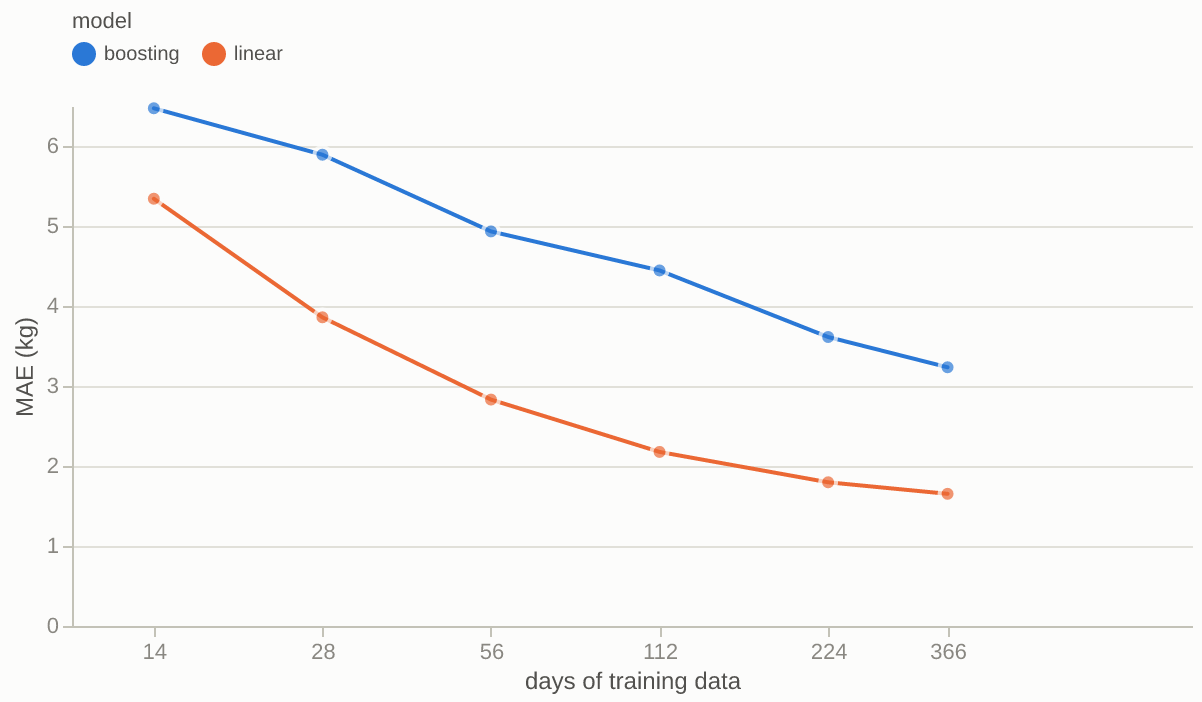

model,boosting,linear
days of training data,,
14,6.47,5.34
28,5.89,3.86
56,4.93,2.83
112,4.44,2.18
224,3.61,1.80
366,3.23,1.65


In [10]:
models = pd.DataFrame(
    [
        {
            "days of training data": n,
            "model": m,
            "MAE (kg)": np.mean(
                [
                    fit_score(
                        train[FEATURES][subset(n, k)], recorded["imprecise"][subset(n, k)], m
                    )[0]
                    for k in range(3)
                ]
            ),
        }
        for m in ("linear", "boosting")
        for n in SIZES
    ]
)
base = alt.Chart(models).encode(
    x=alt.X("days of training data:Q", scale=alt.Scale(type="log"), axis=alt.Axis(values=SIZES)),
    y=alt.Y("MAE (kg):Q", scale=alt.Scale(zero=True)),
    color=alt.Color("model:N"),
    tooltip=["model", "days of training data", alt.Tooltip("MAE (kg):Q", format=".2f")],
)
display((base.mark_line() + base.mark_point()).properties(width=560, height=260))
display(models.pivot(index="days of training data", columns="model", values="MAE (kg)").round(2))

In [11]:
bands = []
for c in ["imprecise", "inaccurate"]:
    q = {}
    for alpha in (0.1, 0.5, 0.9):
        m = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=alpha,
            max_iter=100,
            categorical_features=[0, 1],
            random_state=0,
        )
        q[alpha] = m.fit(train[FEATURES], recorded[c]).predict(test[FEATURES])
    bands.append(
        pd.DataFrame(
            {
                "date": test.date,
                "store_id": test.store_id,
                "data": c,
                "low": q[0.1],
                "median": q[0.5],
                "high": q[0.9],
                "true": test.sales,
            }
        )
    )
bands = pd.concat(bands)
coverage = (
    bands.groupby("data")
    .apply(
        lambda b: pd.Series(
            {
                "true value inside the 80 % interval": np.mean(
                    (b.true >= b.low) & (b.true <= b.high)
                ),
                "interval width (kg)": (b.high - b.low).mean(),
            }
        ),
        include_groups=False,
    )
    .round(2)
)

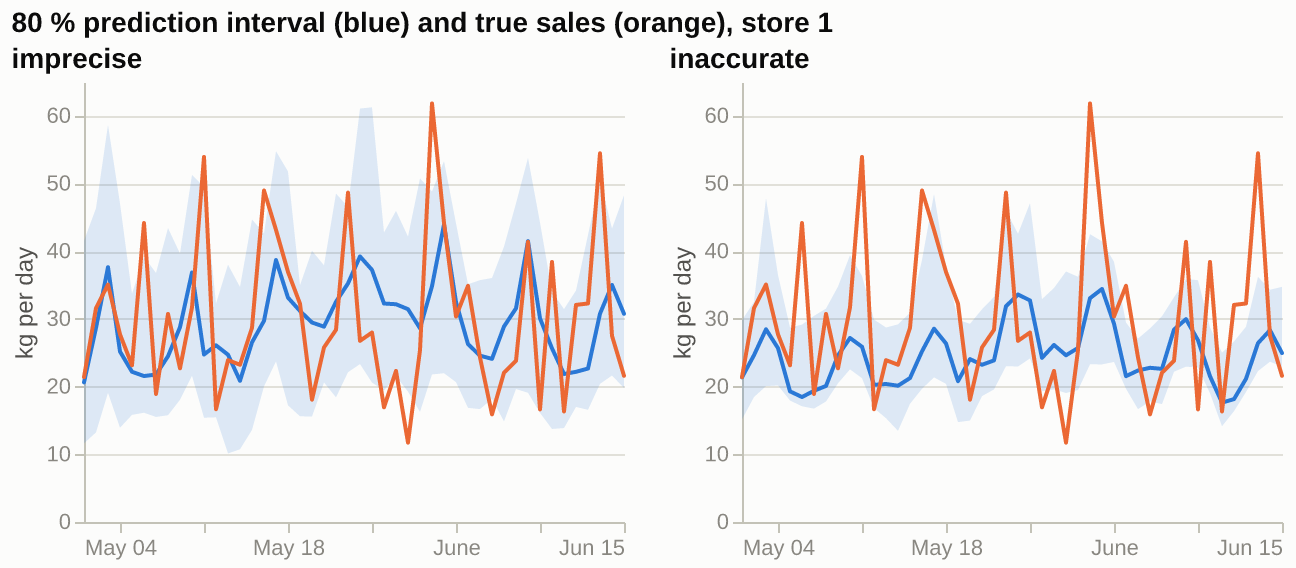

,true value inside the 80 % interval,interval width (kg)
data,,
imprecise,0.82,23.62
inaccurate,0.60,14.52


In [12]:
window = bands[(bands.store_id == 1) & bands.date.between("2025-05-01", "2025-06-15")]
band = (
    alt.Chart()
    .mark_area(opacity=0.15, color="#2a78d6")
    .encode(x=alt.X("date:T", title=None), y=alt.Y("low:Q", title="kg per day"), y2="high:Q")
)
median = alt.Chart().mark_line(color="#2a78d6").encode(x="date:T", y="median:Q")
true = (
    alt.Chart()
    .mark_line(color="#eb6834", strokeWidth=2)
    .encode(
        x="date:T",
        y="true:Q",
        tooltip=[
            alt.Tooltip("date:T"),
            alt.Tooltip("true:Q", format=".1f"),
            alt.Tooltip("low:Q", format=".1f"),
            alt.Tooltip("high:Q", format=".1f"),
        ],
    )
)
charts = [
    alt.layer(band, median, true, data=window[window.data == k]).properties(
        width=270, height=220, title=k
    )
    for k in ("imprecise", "inaccurate")
]
chart = alt.hconcat(*charts).properties(
    title="80 % prediction interval (blue) and true sales (orange), store 1"
)
display(chart)
display(coverage)

## What to take away

- **Imprecise data** (noise) → the model is less confident (wide intervals) and needs more
  data; with enough data the noise averages out.
- **Inaccurate data** (bias) → the model is confident but wrong (narrow intervals in the
  wrong place). More data does not help: the error stays at the level of the bias.
- A more complex model does not fix bad data; with little, noisy data a simple model can be
  better. Invest in the *right* data, not only in more data.